# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama:Nasikhun Amin
- Email:nasikhunamin1011@gmail.com
- Id Dicoding:nasikhun_amin

## Persiapan
### Menyiapkan library yang dibutuhkan

 Pada tahap ini, kita memuat semua pustaka (library) yang diperlukan untuk eksplorasi data, preprocessing, pemodelan (menggunakan XGBoost), dan evaluasi metrik kinerja model.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score)
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})
RANDOM_STATE = 42
print("Library berhasil dimuat!")

Library berhasil dimuat!


### Menyiapkan data yang akan digunakan

 Mendefinisikan *Business Understanding* dan memuat dataset dari `dataset/data.csv`. Di sini kita melihat distribusi target dari pendaftaran mahasiswa, yang terbagi ke dalam kelas Dropout, Enrolled, dan Graduate.

In [8]:
# BUSINESS UNDERSTANDING
print("JAYA JAYA INSTITUT - Student Dropout Prediction System")
print("Problem Statement: Jaya Jaya Institut menghadapi tingkat dropout tinggi, berdampak pada finansial.")
print("Tujuan Bisnis: Mengurangi dropout rate via early warning system.")
print("Success Metrics: Macro F1-Score yang baik, fokus prediksi akurat pada kelas Dropout.")

# Memuat Data
df = pd.read_csv('dataset/data.csv', sep=';')
print(f"\nDataset Shape: {df.shape}")
print("\nDistribusi Target (Status):")
for status, count in df['Status'].value_counts().items():
    print(f"  {status}: {count} ({count / len(df) * 100:.1f}%)")
df.head()

JAYA JAYA INSTITUT - Student Dropout Prediction System
Problem Statement: Jaya Jaya Institut menghadapi tingkat dropout tinggi, berdampak pada finansial.
Tujuan Bisnis: Mengurangi dropout rate via early warning system.
Success Metrics: Macro F1-Score yang baik, fokus prediksi akurat pada kelas Dropout.

Dataset Shape: (4424, 37)

Distribusi Target (Status):
  Graduate: 2209 (49.9%)
  Dropout: 1421 (32.1%)
  Enrolled: 794 (17.9%)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Exploratory Data Analysis (EDA) dilakukan di sini untuk memahami data kita.
1. Mengecek missing values.
2. Memvisualisasikan distribusi status mahasiswa.
3. Melakukan pengecekan distribusi berdasarkan faktor akademik (GPA) dan pembayaran akademik (Tuition Fees) yang penting untuk indikator dropout.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

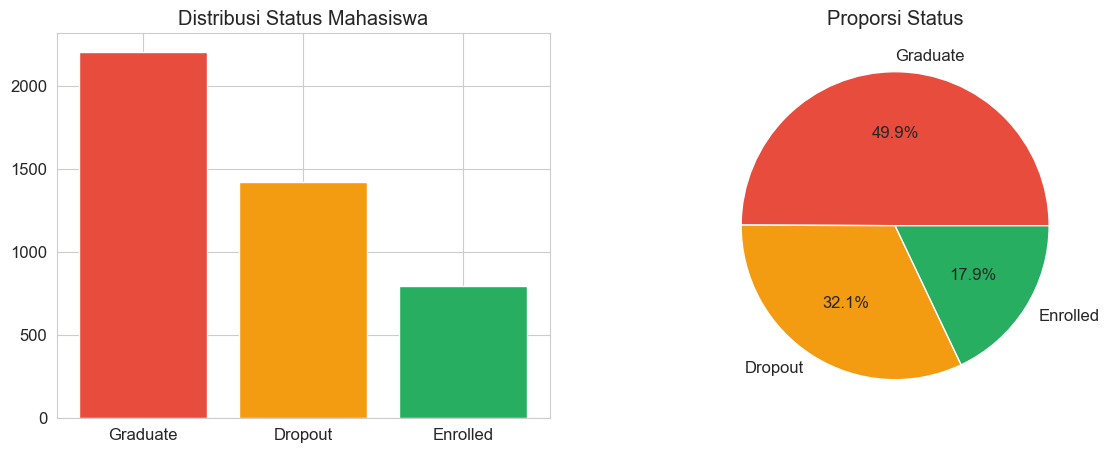

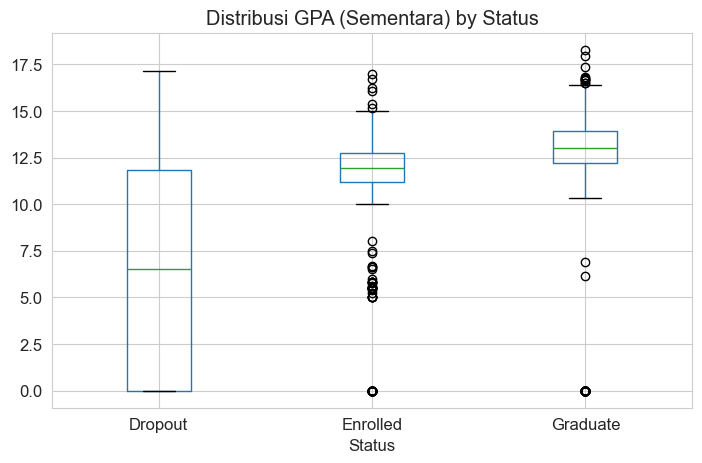

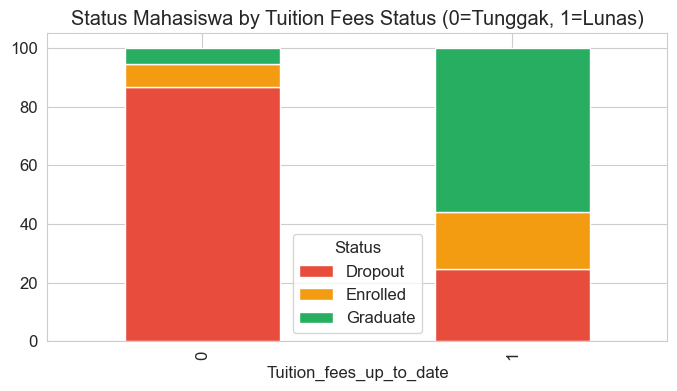

In [9]:
df.info()
print(f"\nMissing values: {df.isnull().sum().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
status_counts = df['Status'].value_counts()
axes[0].bar(status_counts.index, status_counts.values, color=['#e74c3c', '#f39c12', '#27ae60'])
axes[0].set_title('Distribusi Status Mahasiswa')

pcts = df['Status'].value_counts(normalize=True)
axes[1].pie(pcts.values, labels=pcts.index, autopct='%1.1f%%', colors=['#e74c3c', '#f39c12', '#27ae60'])
axes[1].set_title('Proporsi Status')
plt.show()

# Rata-rata GPA 
df['GPA_temp'] = (df['Curricular_units_1st_sem_grade'] + df['Curricular_units_2nd_sem_grade']) / 2
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='GPA_temp', by='Status', ax=ax)
ax.set_title('Distribusi GPA (Sementara) by Status')
plt.suptitle('')
plt.show()

# Analisis Biaya Pendidikans
tuit = df.groupby(['Tuition_fees_up_to_date', 'Status']).size().unstack(fill_value=0)
tuit_pct = tuit.div(tuit.sum(axis=1), axis=0) * 100
tuit_pct.plot(kind='bar', stacked=True, color=['#e74c3c', '#f39c12', '#27ae60'], figsize=(8, 4))
plt.title('Status Mahasiswa by Tuition Fees Status (0=Tunggak, 1=Lunas)')
plt.show()

## Data Preparation / Preprocessing

Tahap pemrosesan data:
1. **Feature Engineering**: Membuat fitur *GPA*, *Approval Rate*, *Failures*, dan *Risk Score* dari riwayat akademik semester 1 dan 2.
2. **Encoding**: Melakukan Label Encoding untuk target `Status` ke numerik.
3. **Data Splitting**: Memisahkan dataset menjadi *Training Set* (80%) dan *Test Set* (20%) dengan *stratified split* agar distribusi target berimbang.

In [10]:
# Feature Engineering
df['GPA'] = df['GPA_temp']
df.drop('GPA_temp', axis=1, inplace=True)
df['Total_approved'] = df['Curricular_units_1st_sem_approved'] + df['Curricular_units_2nd_sem_approved']
df['Total_enrolled'] = df['Curricular_units_1st_sem_enrolled'] + df['Curricular_units_2nd_sem_enrolled']
df['Approval_rate'] = (df['Total_approved'] / (df['Total_enrolled'] + 1e-9)).clip(0, 1)
df['Total_evaluations'] = df['Curricular_units_1st_sem_evaluations'] + df['Curricular_units_2nd_sem_evaluations']
df['Absences'] = df['Curricular_units_1st_sem_without_evaluations'] + df['Curricular_units_2nd_sem_without_evaluations']
df['Failures'] = (df['Total_enrolled'] - df['Total_approved']).clip(lower=0)
df['Risk_score'] = df['Failures'] * (df['Absences'] + 1) / (df['GPA'] + 1)
df['Grade_diff'] = df['Curricular_units_2nd_sem_grade'] - df['Curricular_units_1st_sem_grade']

print("Fitur ditambahkan: GPA, Approval_rate, Absences, Failures, Risk_score, dll.")

le = LabelEncoder()
df['Status_encoded'] = le.fit_transform(df['Status'])
print(f"Label Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

features = [c for c in df.columns if c not in ['Status', 'Status_encoded']]
X = df[features].copy()
y = df['Status_encoded'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train set: {X_train.shape[0]} | Test set: {X_test.shape[0]}")

Fitur ditambahkan: GPA, Approval_rate, Absences, Failures, Risk_score, dll.
Label Encoding: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Train set: 3539 | Test set: 885


## Modeling

Pada tahap ini, model dibangun menggunakan kombinasi **StandardScaler** untuk standarisasi dan classifier untuk klasifikasi, dengan proses hyperparameter tuning menggunakan **GridSearchCV** (5-fold cross-validation) yang dioptimalkan berdasarkan skor **F1 Macro**.

In [11]:
# XGBoost 
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss', use_label_encoder=False))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 6],
    'clf__learning_rate': [0.05, 0.1]
}

print("Tuning XGBoost Model dengan GridSearchCV...")
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(f"Best params: {grid.best_params_}")
print(f"Best CV F1 Macro: {grid.best_score_:.3f}")

Tuning XGBoost Model dengan GridSearchCV...
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Best CV F1 Macro: 0.712


## Evaluation

Mengevaluasi kinerja model XGBoost terhadap test set menggunakan metrik:
- **Classification Report** (Precision, Recall, F1 for Dropout).
- **Confusion Matrix** (Prediksi Aktual vs Model).
- **Feature Importance** (Faktor yang paling mendorong algoritma untuk memprediksi Dropout).
Selanjutnya, kita menyimpan sekumpulan data pipeline untuk di-load lewat aplikasi Streamlit.

Classification Report 
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.56      0.43      0.48       159
    Graduate       0.81      0.91      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.76      0.77      0.77       885

Macro F1-Score: 0.707


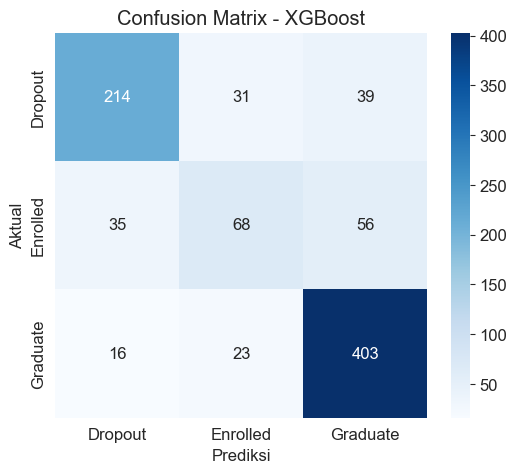


Model XGBoost berhasil disimpan ke model/model.joblib!


In [12]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

target_names = list(le.classes_)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print("Classification Report ")
print(classification_report(y_test, y_pred, target_names=target_names))
print(f"Macro F1-Score: {macro_f1:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Simpan Model ke direktori model/
os.makedirs('model', exist_ok=True)
model_data = {
    'model': best_model,
    'feature_names': features,
    'label_encoder': le,
    'best_model_name': 'XGBoost'
}
joblib.dump(model_data, 'model/model.joblib')
print("\nModel XGBoost berhasil disimpan ke model/model.joblib!")